# Mathematical Formulations of Gradient-Based Optimizers

Below are the update equations for each implemented optimization algorithm. Let $J(\theta)$ be the loss, $g_t=\nabla_\theta J(\theta_t)$, and $\alpha$ the learning rate.

---

**1. Gradient Descent (GD)**
$$
\theta_{t+1} = \theta_t - \alpha \, \nabla_\theta J(\theta_t)
$$

**2. Stochastic Gradient Descent (SGD)**
$$
\theta_{t+1} = \theta_t - \alpha \, \nabla_\theta J(\theta_t; x^{(i)}, y^{(i)})
$$

**3. SGD with Momentum**
$$
v_t = \beta \, v_{t-1} + (1 - \beta) \, g_t,\quad
\theta_{t+1} = \theta_t - \alpha \, v_t
$$

**4. Nesterov Accelerated Gradient**
$$
v_t = \beta \, v_{t-1} + \alpha \, \nabla_\theta J(\theta_t - \beta \, v_{t-1}),\\
\theta_{t+1} = \theta_t - v_t
$$

**5. Adagrad**
$$
G_t = G_{t-1} + g_t \odot g_t,\\
\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{G_t + \epsilon}} \odot g_t
$$

**6. RMSprop**
$$
s_t = \beta \, s_{t-1} + (1-\beta) \, g_t \odot g_t,\\
\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{s_t + \epsilon}} \odot g_t
$$

**7. Adadelta**
$$
E[g^2]_t = \rho E[g^2]_{t-1} + (1-\rho) \, g_t \odot g_t,\\
\Delta \theta_t = -\frac{\sqrt{E[\Delta \theta^2]_{t-1}+\epsilon}}{\sqrt{E[g^2]_t+\epsilon}}\odot g_t,\\
E[\Delta \theta^2]_t = \rho E[\Delta \theta^2]_{t-1} + (1-\rho)\,\Delta \theta_t \odot \Delta \theta_t
$$

**8. Adam**
$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) \, g_t,\\
v_t = \beta_2 v_{t-1} + (1-\beta_2) \, g_t^2,\\
\hat m_t = \frac{m_t}{1-\beta_1^t},\quad \hat v_t = \frac{v_t}{1-\beta_2^t},\\
\theta_{t+1} = \theta_t - \alpha \frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}
$$

**9. Adamax**
$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t,\\
u_t = \max(\beta_2 \nu_{t-1}, |g_t|),\\
\hat m_t = \frac{m_t}{1-\beta_1^t},\\
\theta_{t+1} = \theta_t - \alpha \frac{\hat m_t}{\nu_t + \epsilon}
$$

**10. Nadam**
$$
m_t, v_t \text{ as in Adam},\\
\hat m_t = \frac{m_t}{1-\beta_1^t},\quad \hat v_t = \frac{v_t}{1-\beta_2^t},\\
\tilde m_t = \beta_1 \hat m_t + \frac{(1-\beta_1)}{1-\beta_1^t} g_t,\\
\theta_{t+1} = \theta_t - \alpha \frac{\tilde m_t}{\sqrt{\hat v_t} + \epsilon}
$$

**11. QHM (Quasi-Hyperbolic Momentum)**
$$
v_t = \beta \, v_{t-1} + (1-\beta) \, g_t,\\
\theta_{t+1} = \theta_t - \alpha \big((1-\nu)g_t + \nu v_t\big)
$$

**12. QHAdam (Quasi-Hyperbolic Adam)**
$$
m_t, v_t, \hat m_t, \hat v_t \text{ as in Adam},\\
\theta_{t+1} = \theta_t - \alpha \,\frac{(1-\nu_1)g_t + \nu_1 \hat m_t}{\sqrt{(1-\nu_2)g_t^2 + \nu_2 \hat v_t}+\epsilon}
$$


Epoch 40/200, MSE = 21.1497
Epoch 80/200, MSE = 16.0869
Epoch 120/200, MSE = 12.0981
Epoch 160/200, MSE = 9.0087
Epoch 200/200, MSE = 6.6517
Learned parameters: {'w': array([ 1.52146755, -1.67680032]), 'b': array(1.77145803)}
True parameters: {'w': array([ 2., -3.]), 'b': 4.0}


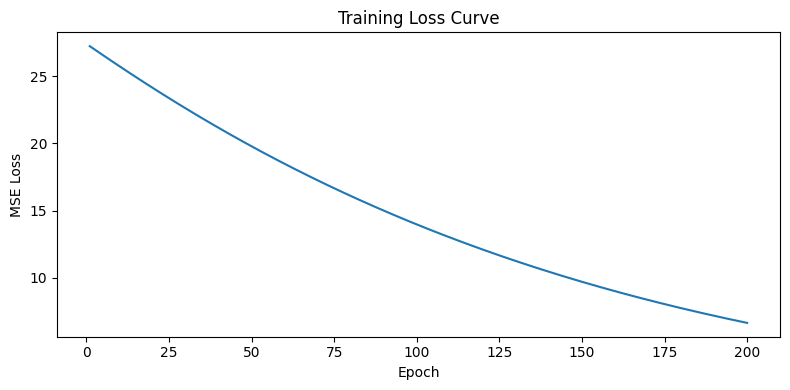

In [1]:
# Gradient Descent Optimization Algorithms

import numpy as np
from abc import ABC, abstractmethod
from typing import Iterator, Tuple, Dict
import matplotlib.pyplot as plt

# -- Data Generation ------------------------------------------------
def generate_linear_data(
    w_true: np.ndarray, b_true: float, n_samples: int = 100, noise_std: float = 1.0
) -> Tuple[np.ndarray, np.ndarray]:
    X = np.random.randn(n_samples, w_true.shape[0])
    y = X.dot(w_true) + b_true + np.random.randn(n_samples) * noise_std
    return X, y

# -- Model Definition ------------------------------------------------
class LinearRegression:
    def __init__(self, n_features: int):
        self.w = np.zeros(n_features)
        self.b = 0.0

    def predict(self, X: np.ndarray) -> np.ndarray:
        return X.dot(self.w) + self.b

    def gradients(self, X: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, float]:
        N = X.shape[0]
        y_hat = self.predict(X)
        error = y_hat - y
        dw = (2.0 / N) * X.T.dot(error)
        db = (2.0 / N) * error.sum()
        return dw, db

    def parameters(self) -> Dict[str, np.ndarray]:
        return {"w": self.w.copy(), "b": np.array(self.b)}

# -- Optimizer Base Class -------------------------------------------
class Optimizer(ABC):
    def __init__(self, lr: float = 0.01):
        self.lr = lr

    @abstractmethod
    def step(self, model: LinearRegression, dw: np.ndarray, db: float) -> None:
        pass

# -- All Optimizer Implementations ----------------------------------
class SGD(Optimizer):
    def step(self, model: LinearRegression, dw: np.ndarray, db: float) -> None:
        model.w -= self.lr * dw
        model.b -= self.lr * db

class SGDMomentum(Optimizer):
    def __init__(self, lr: float = 0.01, momentum: float = 0.9):
        super().__init__(lr)
        self.momentum = momentum
        self.v_w = None
        self.v_b = 0.0

    def step(self, model: LinearRegression, dw: np.ndarray, db: float) -> None:
        if self.v_w is None:
            self.v_w = np.zeros_like(dw)
            self.v_b = 0.0
        self.v_w = self.momentum * self.v_w + self.lr * dw
        self.v_b = self.momentum * self.v_b + self.lr * db
        model.w -= self.v_w
        model.b -= self.v_b

class Nesterov(Optimizer):
    def __init__(self, lr: float = 0.01, momentum: float = 0.9):
        super().__init__(lr)
        self.momentum = momentum
        self.v_w = None
        self.v_b = 0.0

    def step(self, model: LinearRegression, dw: np.ndarray, db: float) -> None:
        if self.v_w is None:
            self.v_w = np.zeros_like(dw)
            self.v_b = 0.0
        prev_v_w = self.v_w.copy()
        prev_v_b = self.v_b
        self.v_w = self.momentum * self.v_w - self.lr * dw
        self.v_b = self.momentum * self.v_b - self.lr * db
        model.w += -self.momentum * prev_v_w + (1 + self.momentum) * self.v_w
        model.b += -self.momentum * prev_v_b + (1 + self.momentum) * self.v_b

class RMSProp(Optimizer):
    def __init__(self, lr: float = 0.001, beta: float = 0.9, eps: float = 1e-8):
        super().__init__(lr)
        self.beta = beta
        self.eps = eps
        self.s_w = None
        self.s_b = 0.0

    def step(self, model: LinearRegression, dw: np.ndarray, db: float) -> None:
        if self.s_w is None:
            self.s_w = np.zeros_like(dw)
            self.s_b = 0.0
        self.s_w = self.beta * self.s_w + (1 - self.beta) * (dw**2)
        self.s_b = self.beta * self.s_b + (1 - self.beta) * (db**2)
        model.w -= (self.lr / (np.sqrt(self.s_w) + self.eps)) * dw
        model.b -= (self.lr / (np.sqrt(self.s_b) + self.eps)) * db

class Adagrad(Optimizer):
    def __init__(self, lr: float = 0.01, eps: float = 1e-8):
        super().__init__(lr)
        self.eps = eps
        self.G_w = None
        self.G_b = 0.0

    def step(self, model: LinearRegression, dw: np.ndarray, db: float) -> None:
        if self.G_w is None:
            self.G_w = np.zeros_like(dw)
            self.G_b = 0.0
        self.G_w += dw ** 2
        self.G_b += db ** 2
        model.w -= self.lr * dw / (np.sqrt(self.G_w) + self.eps)
        model.b -= self.lr * db / (np.sqrt(self.G_b) + self.eps)

class Adadelta(Optimizer):
    def __init__(self, rho: float = 0.95, eps: float = 1e-6):
        super().__init__(lr=1.0)  # lr is internally calculated
        self.rho = rho
        self.eps = eps
        self.Eg_w = None
        self.Edx_w = None
        self.Eg_b = 0.0
        self.Edx_b = 0.0

    def step(self, model: LinearRegression, dw: np.ndarray, db: float) -> None:
        if self.Eg_w is None:
            self.Eg_w = np.zeros_like(dw)
            self.Edx_w = np.zeros_like(dw)
        self.Eg_w = self.rho * self.Eg_w + (1 - self.rho) * (dw ** 2)
        self.Eg_b = self.rho * self.Eg_b + (1 - self.rho) * (db ** 2)

        dx_w = -np.sqrt(self.Edx_w + self.eps) / np.sqrt(self.Eg_w + self.eps) * dw
        dx_b = -np.sqrt(self.Edx_b + self.eps) / np.sqrt(self.Eg_b + self.eps) * db

        model.w += dx_w
        model.b += dx_b

        self.Edx_w = self.rho * self.Edx_w + (1 - self.rho) * (dx_w ** 2)
        self.Edx_b = self.rho * self.Edx_b + (1 - self.rho) * (dx_b ** 2)

class Adam(Optimizer):
    def __init__(self, lr: float = 0.001, beta1: float = 0.9, beta2: float = 0.999, eps: float = 1e-8):
        super().__init__(lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m_w = None
        self.v_w = None
        self.m_b = 0.0
        self.v_b = 0.0
        self.t = 0

    def step(self, model: LinearRegression, dw: np.ndarray, db: float) -> None:
        if self.m_w is None:
            self.m_w = np.zeros_like(dw)
            self.v_w = np.zeros_like(dw)
        self.t += 1
        self.m_w = self.beta1 * self.m_w + (1 - self.beta1) * dw
        self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * db
        self.v_w = self.beta2 * self.v_w + (1 - self.beta2) * (dw**2)
        self.v_b = self.beta2 * self.v_b + (1 - self.beta2) * (db**2)
        m_w_hat = self.m_w / (1 - self.beta1**self.t)
        m_b_hat = self.m_b / (1 - self.beta1**self.t)
        v_w_hat = self.v_w / (1 - self.beta2**self.t)
        v_b_hat = self.v_b / (1 - self.beta2**self.t)
        model.w -= self.lr * m_w_hat / (np.sqrt(v_w_hat) + self.eps)
        model.b -= self.lr * m_b_hat / (np.sqrt(v_b_hat) + self.eps)

class Adamax(Adam):
    def __init__(self, lr: float = 0.002, beta1: float = 0.9, beta2: float = 0.999, eps: float = 1e-8):
        super().__init__(lr, beta1, beta2, eps)
        self.u_w = None
        self.u_b = 0.0

    def step(self, model: LinearRegression, dw: np.ndarray, db: float) -> None:
        if self.m_w is None:
            self.m_w = np.zeros_like(dw)
            self.u_w = np.zeros_like(dw)
        self.t += 1
        self.m_w = self.beta1 * self.m_w + (1 - self.beta1) * dw
        self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * db
        self.u_w = np.maximum(self.beta2 * self.u_w, np.abs(dw))
        self.u_b = max(self.beta2 * self.u_b, abs(db))
        model.w -= self.lr * self.m_w / (self.u_w + self.eps)
        model.b -= self.lr * self.m_b / (self.u_b + self.eps)

class Nadam(Adam):
    def step(self, model: LinearRegression, dw: np.ndarray, db: float) -> None:
        if self.m_w is None:
            self.m_w = np.zeros_like(dw)
            self.v_w = np.zeros_like(dw)
        self.t += 1
        self.m_w = self.beta1 * self.m_w + (1 - self.beta1) * dw
        self.v_w = self.beta2 * self.v_w + (1 - self.beta2) * (dw**2)
        self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * db
        self.v_b = self.beta2 * self.v_b + (1 - self.beta2) * (db**2)

        m_w_hat = self.m_w / (1 - self.beta1**self.t)
        v_w_hat = self.v_w / (1 - self.beta2**self.t)
        m_b_hat = self.m_b / (1 - self.beta1**self.t)
        v_b_hat = self.v_b / (1 - self.beta2**self.t)

        m_w_nesterov = self.beta1 * m_w_hat + (1 - self.beta1) * dw / (1 - self.beta1 ** self.t)
        m_b_nesterov = self.beta1 * m_b_hat + (1 - self.beta1) * db / (1 - self.beta1 ** self.t)

        model.w -= self.lr * m_w_nesterov / (np.sqrt(v_w_hat) + self.eps)
        model.b -= self.lr * m_b_nesterov / (np.sqrt(v_b_hat) + self.eps)

class QHM(Optimizer):
    def __init__(self, lr: float = 0.01, beta: float = 0.9, nu: float = 1.0):
        super().__init__(lr)
        self.beta = beta
        self.nu = nu
        self.v_w = None
        self.v_b = 0.0

    def step(self, model: LinearRegression, dw: np.ndarray, db: float) -> None:
        if self.v_w is None:
            self.v_w = np.zeros_like(dw)
            self.v_b = 0.0
        self.v_w = self.beta * self.v_w + (1 - self.beta) * dw
        self.v_b = self.beta * self.v_b + (1 - self.beta) * db
        model.w -= self.lr * ((1 - self.nu) * dw + self.nu * self.v_w)
        model.b -= self.lr * ((1 - self.nu) * db + self.nu * self.v_b)

class QHAdam(Adam):
    def __init__(self, lr: float = 0.001, beta1: float = 0.9, beta2: float = 0.999, eps: float = 1e-8, nu1: float = 1.0, nu2: float = 1.0):
        super().__init__(lr, beta1, beta2, eps)
        self.nu1 = nu1
        self.nu2 = nu2

    def step(self, model: LinearRegression, dw: np.ndarray, db: float) -> None:
        if self.m_w is None:
            self.m_w = np.zeros_like(dw)
            self.v_w = np.zeros_like(dw)
        self.t += 1
        self.m_w = self.beta1 * self.m_w + (1 - self.beta1) * dw
        self.v_w = self.beta2 * self.v_w + (1 - self.beta2) * (dw**2)
        self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * db
        self.v_b = self.beta2 * self.v_b + (1 - self.beta2) * (db**2)

        m_w_hat = self.m_w / (1 - self.beta1 ** self.t)
        v_w_hat = self.v_w / (1 - self.beta2 ** self.t)
        m_b_hat = self.m_b / (1 - self.beta1 ** self.t)
        v_b_hat = self.v_b / (1 - self.beta2 ** self.t)

        model.w -= self.lr * ((1 - self.nu1) * dw + self.nu1 * m_w_hat) / (np.sqrt((1 - self.nu2) * (dw ** 2) + self.nu2 * v_w_hat) + self.eps)
        model.b -= self.lr * ((1 - self.nu1) * db + self.nu1 * m_b_hat) / (np.sqrt((1 - self.nu2) * (db ** 2) + self.nu2 * v_b_hat) + self.eps)

# -- Training Loop ---------------------------------------------------
def train(
    model: LinearRegression,
    optimizer: Optimizer,
    X: np.ndarray,
    y: np.ndarray,
    n_epochs: int = 100,
) -> Tuple[np.ndarray, np.ndarray]:
    history = []
    for epoch in range(1, n_epochs + 1):
        dw, db = model.gradients(X, y)
        optimizer.step(model, dw, db)
        mse = np.mean((model.predict(X) - y) ** 2)
        history.append(mse)
        if epoch % (n_epochs // 5) == 0:
            print(f"Epoch {epoch}/{n_epochs}, MSE = {mse:.4f}")
    return np.arange(1, n_epochs + 1), np.array(history)

# -- Example Usage ---------------------------------------------------
if __name__ == "__main__":
    np.random.seed(42)
    w_true = np.array([2.0, -3.0])
    b_true = 4.0
    X, y = generate_linear_data(w_true, b_true, n_samples=200, noise_std=0.5)

    model = LinearRegression(n_features=2)

    optimizer = Adam(lr=0.01)

    epochs, loss_history = train(model, optimizer, X, y, n_epochs=200)

    print("Learned parameters:", model.parameters())
    print("True parameters:", {"w": w_true, "b": b_true})

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, loss_history)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Training Loss Curve")
    plt.tight_layout()
    plt.show()